In [ ]:
#Merging movie CSV files for different languages
import pandas as pd

def merge_movie_csvs(lang_prefix):
    # File names
    base_file = f"{lang_prefix}_movies_genres_filled.csv"
    overview_file = f"{lang_prefix}_movies_overview.csv"
    votes_file = f"{lang_prefix}_movies_votes.csv"
    output_file = f"{lang_prefix}_movies.csv"

    # Load CSVs
    try:
        df_base = pd.read_csv(base_file, encoding='ISO-8859-1')
        df_overview = pd.read_csv(overview_file, encoding='ISO-8859-1')
        df_votes = pd.read_csv(votes_file, encoding='ISO-8859-1')

    except Exception as e:
        print(f"Error reading files for {lang_prefix}: {e}")
        return

    # Merge on Title (movie name)
    df_merged = df_base.merge(df_overview, on="Title", how="outer")
    df_merged = df_merged.merge(df_votes, on="Title", how="outer")

    # Optional: Drop duplicates
    df_merged.drop_duplicates(subset=["Title"], keep='first', inplace=True)

    # Save to final CSV
    df_merged.to_csv(output_file, index=False)
    print(f"Merged {lang_prefix} CSV saved as: {output_file} ({len(df_merged)} movies)")

# Run for each language
merge_movie_csvs("telugu")
merge_movie_csvs("hindi")
merge_movie_csvs("english")
merge_movie_csvs("kannada")


Merged telugu CSV saved as: telugu_movies.csv (3209 movies)
Merged hindi CSV saved as: hindi_movies.csv (8551 movies)
Merged english CSV saved as: english_movies.csv (12570 movies)
Merged kannada CSV saved as: kannada_movies.csv (1820 movies)


In [ ]:
#Removed unnecessary 'Movie ID' column from movie CSVs
languages = ["hindi", "kannada", "english"]

for lang in languages:
    filename = f"{lang}_movies.csv"
    try:
        df = pd.read_csv(filename, encoding='ISO-8859-1')
        if "Movie ID" in df.columns:
            df.drop(columns=["Movie ID"], inplace=True)
            df.to_csv(filename, index=False, encoding='utf-8')
            print(f"Removed 'Movie ID' from {filename}")
        else:
            print(f"ℹ'Movie ID' not found in {filename}")
    except Exception as e:
        print(f"Error processing {filename}: {e}")


ℹ'Movie ID' not found in hindi_movies.csv
ℹ'Movie ID' not found in kannada_movies.csv
Removed 'Movie ID' from english_movies.csv


In [ ]:
#Removing special characters from movie titles in CSV files
import pandas as pd
import re

file_names = ["hindi_movies.csv", "kannada_movies.csv", "english_movies.csv", "telugu_movies.csv"]

for file_path in file_names:
    try:
        df = pd.read_csv(file_path, encoding='utf-8-sig')
    except UnicodeDecodeError:
        df = pd.read_csv(file_path, encoding='latin1')

    for col in df.select_dtypes(include='object'):
        df[col] = df[col].apply(lambda x: re.sub(r'[^\x00-\x7F]+', '', str(x)))

    df.to_csv(file_path, index=False, encoding='utf-8-sig')
    print(f"{file_path}: Cleaned special characters and saved.")

hindi_movies.csv: Cleaned special characters and saved.
kannada_movies.csv: Cleaned special characters and saved.
english_movies.csv: Cleaned special characters and saved.
telugu_movies.csv: Cleaned special characters and saved.


In [ ]:
import pandas as pd

file_names = ["hindi_movies.csv", "kannada_movies.csv", "english_movies.csv", "telugu_movies.csv"]

for file_path in file_names:
    df = pd.read_csv(file_path, encoding='utf-8-sig')
    original_rows = len(df)

    # Clean column names
    df.columns = df.columns.str.strip().str.replace('\u200b', '').str.replace('\ufeff', '')

    if "Title" in df.columns and "Release Date" in df.columns:
        df = df.drop_duplicates(subset=["Title", "Release Date"])
        new_rows = len(df)
        removed = original_rows - new_rows
        df.to_csv(file_path, index=False, encoding='utf-8-sig')
        print(f"{file_path}: Removed {removed} duplicate rows.")
    else:
        print(f"{file_path}: 'Movie Name' or 'Release Date' column not found. Columns present: {df.columns.tolist()}")


hindi_movies.csv: Removed 38 duplicate rows.
kannada_movies.csv: Removed 2 duplicate rows.
english_movies.csv: Removed 24 duplicate rows.
telugu_movies.csv: Removed 12 duplicate rows.


In [ ]:
import pandas as pd

languages = ["telugu", "hindi", "english", "kannada"]
dataframes = {}
base_path = "/content/drive/MyDrive/Movie_Recommendation"

for lang in languages:
    file_path = f"{base_path}/{lang}_movies.csv"
    try:
        df = pd.read_csv(file_path, encoding='utf-8-sig')
    except UnicodeDecodeError:
        df = pd.read_csv(file_path, encoding='latin1')
    dataframes[lang] = df

print("DataFrames loaded:")
for lang, df in dataframes.items():
    print(f"- {lang}: {len(df)} rows, {len(df.columns)} columns")


DataFrames loaded:
- telugu: 3197 rows, 9 columns
- hindi: 8513 rows, 9 columns
- english: 12546 rows, 9 columns
- kannada: 1818 rows, 9 columns


In [ ]:
missing_percentages = {}

for lang, df in dataframes.items():
    missing_percentages[lang] = (df.isnull().sum() / len(df)) * 100

# Display the missing percentages for each language
for lang, missing_series in missing_percentages.items():
    print(f"\nMissing percentages for {lang}:")
    print(missing_series)


Missing percentages for telugu:
Title            0.000000
Language        19.017829
Genres          19.393181
Rating          19.017829
Popularity      19.017829
Release Date    19.017829
Cast            19.017829
Overview         9.727870
Vote_Count       0.688145
dtype: float64

Missing percentages for hindi:
Title            0.011747
Language        21.132386
Genres          21.132386
Rating          21.132386
Popularity      21.132386
Release Date    21.132386
Cast            21.132386
Overview        11.840714
Vote_Count       0.681311
dtype: float64

Missing percentages for english:
Title            0.000000
Language        43.838674
Genres          43.838674
Rating          43.838674
Popularity      43.838674
Release Date    43.838674
Cast            43.838674
Overview        32.544237
Vote_Count      23.569265
dtype: float64

Missing percentages for kannada:
Title            0.110011
Language        14.631463
Genres          14.631463
Rating          14.631463
Popularity      

In [ ]:
missing_df = pd.DataFrame(missing_percentages)

if 'index' in missing_df.columns:
    missing_df = missing_df.reset_index()
    missing_df = missing_df.rename(columns={'index': 'Column Name'})
else:
    missing_df = missing_df.reset_index()
    missing_df = missing_df.rename(columns={'index': 'Column Name'})

display(missing_df)

,Column Name,telugu,hindi,english,kannada
0,Title,0.000000,0.011747,0.000000,0.110011
1,Language,19.017829,21.132386,43.838674,14.631463
2,Genres,19.393181,21.132386,43.838674,14.631463
3,Rating,19.017829,21.132386,43.838674,14.631463
4,Popularity,19.017829,21.132386,43.838674,14.631463
5,Release Date,19.017829,21.132386,43.838674,14.631463
6,Cast,19.017829,21.132386,43.838674,14.631463
7,Overview,9.727870,11.840714,32.544237,12.596260
8,Vote_Count,0.688145,0.681311,23.569265,0.440044


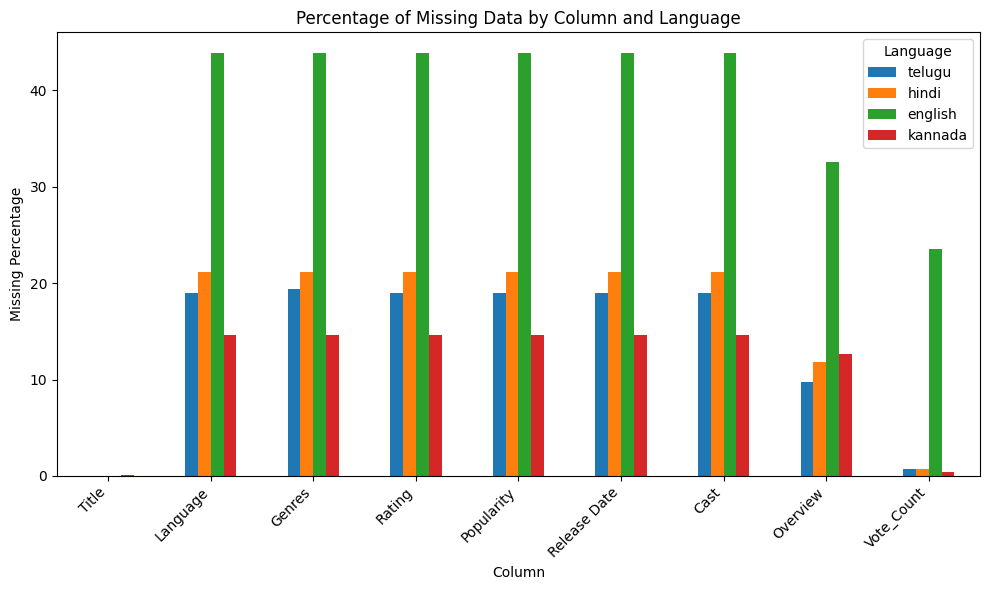

In [ ]:
import matplotlib.pyplot as plt

# Create a bar plot
missing_df.plot(x='Column Name', y=languages, kind='bar', figsize=(10, 6))

# Set the title and labels
plt.title("Percentage of Missing Data by Column and Language")
plt.xlabel("Column")
plt.ylabel("Missing Percentage")

# Rotate x-axis labels for readability
plt.xticks(rotation=45, ha='right')

# Add a legend
plt.legend(title="Language")

# Ensure tight layout
plt.tight_layout()

# Display the plot
plt.show()

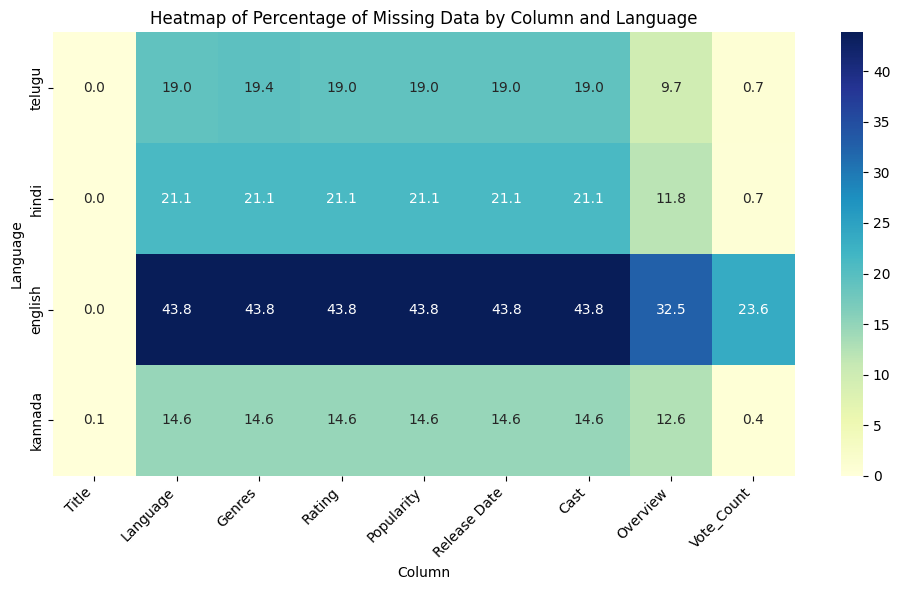

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.heatmap(missing_df.set_index('Column Name').transpose(), annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("Heatmap of Percentage of Missing Data by Column and Language")
plt.xlabel("Column")
plt.ylabel("Language")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np

path = "/content/drive/MyDrive/Movie_Recommendation"
files = ["telugu_movies.csv", "hindi_movies.csv", "english_movies.csv", "kannada_movies.csv"]

dfs = [pd.read_csv(f"{path}/{file}") for file in files]

for i, df in enumerate(dfs, 1):
    print(f"Dataset {i} shape:", df.shape)

Dataset 1 shape: (3197, 9)
Dataset 2 shape: (8513, 9)
Dataset 3 shape: (12546, 9)
Dataset 4 shape: (1818, 9)


In [ ]:
def clean_dataset(df):
    df.drop_duplicates(inplace=True)
    df.reset_index(drop=True, inplace=True)
    if 'Rating' in df.columns:
        df['Rating'] = df['Rating'].replace(0, np.nan)
        df['Rating'] = df.groupby('Language')['Rating'].transform(lambda x: x.fillna(x.median()))
    text_columns = ['Overview', 'Genres', 'Cast']
    for col in text_columns:
        if col in df.columns:
            df[col] = df[col].fillna("Unknown")
    numeric_columns = df.select_dtypes(include=[np.number]).columns
    for col in numeric_columns:
        df[col] = df[col].fillna(df[col].median())
    for col in df.select_dtypes(include='object').columns:
        df[col] = df[col].str.lower().str.strip()
    if 'Vote_Count' in df.columns:
        df = df[df['Vote_Count'] <= df['Vote_Count'].quantile(0.99)]
    if 'Popularity' in df.columns:
        df = df[df['Popularity'] <= df['Popularity'].quantile(0.99)]
    return df


In [ ]:
#Cleaning
cleaned_dfs = [clean_dataset(df) for df in dfs]

for i, df in enumerate(cleaned_dfs, 1):
    print(f"Cleaned Dataset {i} shape:", df.shape)

Cleaned Dataset 1 shape: (3133, 9)
Cleaned Dataset 2 shape: (8343, 9)
Cleaned Dataset 3 shape: (12295, 9)
Cleaned Dataset 4 shape: (1782, 9)


In [ ]:
#Combining
movies = pd.concat(cleaned_dfs, ignore_index=True)

# Re-run cleaning after combining
movies = clean_dataset(movies)

print("Final combined shape:", movies.shape)

Final combined shape: (25044, 9)


In [ ]:
#To Drive
movies.to_csv(f"{path}/movies.csv", index=False)
print("Final cleaned dataset saved at:", f"{path}/movies.csv")

Final cleaned dataset saved at: /content/drive/MyDrive/Movie_Recommendation/movies.csv


/tmp/ipython-input-2384921960.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=(movies['Vote_Count'] <= low_vote_threshold), palette='coolwarm')
/tmp/ipython-input-2384921960.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=(movies['Rating'] <= low_rating_threshold), palette='viridis')
/tmp/ipython-input-2384921960.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=(movies['Popularity'] <= low_popularity_threshold), palette='plasma')


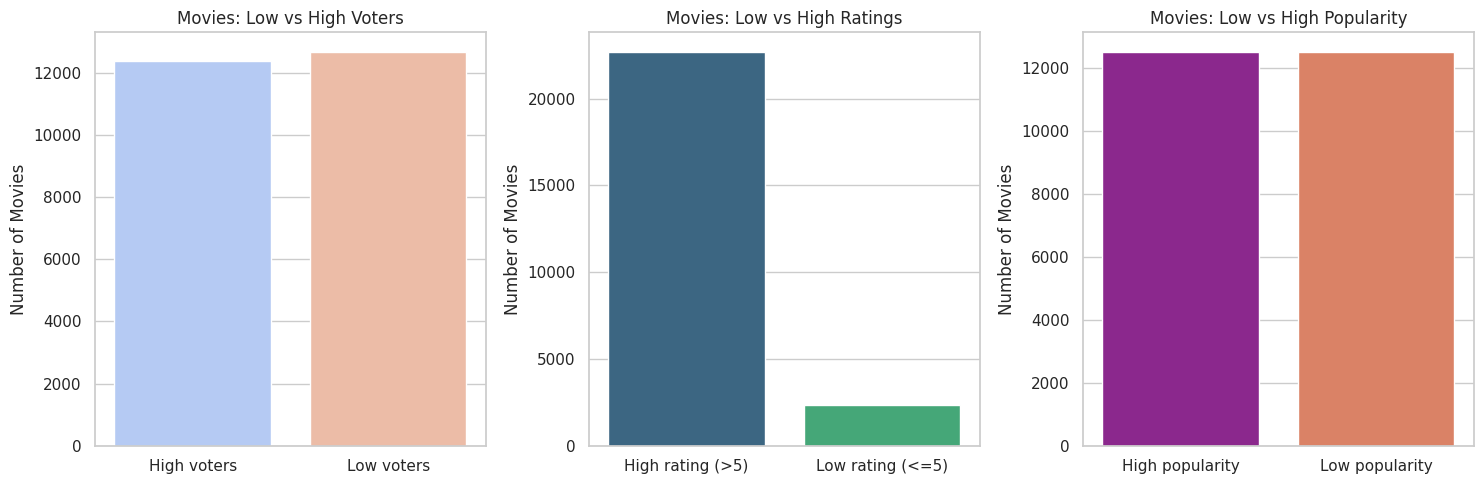

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.figure(figsize=(15, 5))

#Vote Count Check
plt.subplot(1, 3, 1)
low_vote_threshold = movies['Vote_Count'].median()
sns.countplot(x=(movies['Vote_Count'] <= low_vote_threshold), palette='coolwarm')
plt.xticks([0, 1], ['High voters', 'Low voters'])
plt.title('Movies: Low vs High Voters')
plt.ylabel('Number of Movies')
plt.xlabel('')

#Rating Check
plt.subplot(1, 3, 2)
low_rating_threshold = 5  # 0–10 scale
sns.countplot(x=(movies['Rating'] <= low_rating_threshold), palette='viridis')
plt.xticks([0, 1], ['High rating (>5)', 'Low rating (<=5)'])
plt.title('Movies: Low vs High Ratings')
plt.ylabel('Number of Movies')
plt.xlabel('')

#Popularity Check
plt.subplot(1, 3, 3)
low_popularity_threshold = movies['Popularity'].median()
sns.countplot(x=(movies['Popularity'] <= low_popularity_threshold), palette='plasma')
plt.xticks([0, 1], ['High popularity', 'Low popularity'])
plt.title('Movies: Low vs High Popularity')
plt.ylabel('Number of Movies')
plt.xlabel('')

plt.tight_layout()
plt.show()


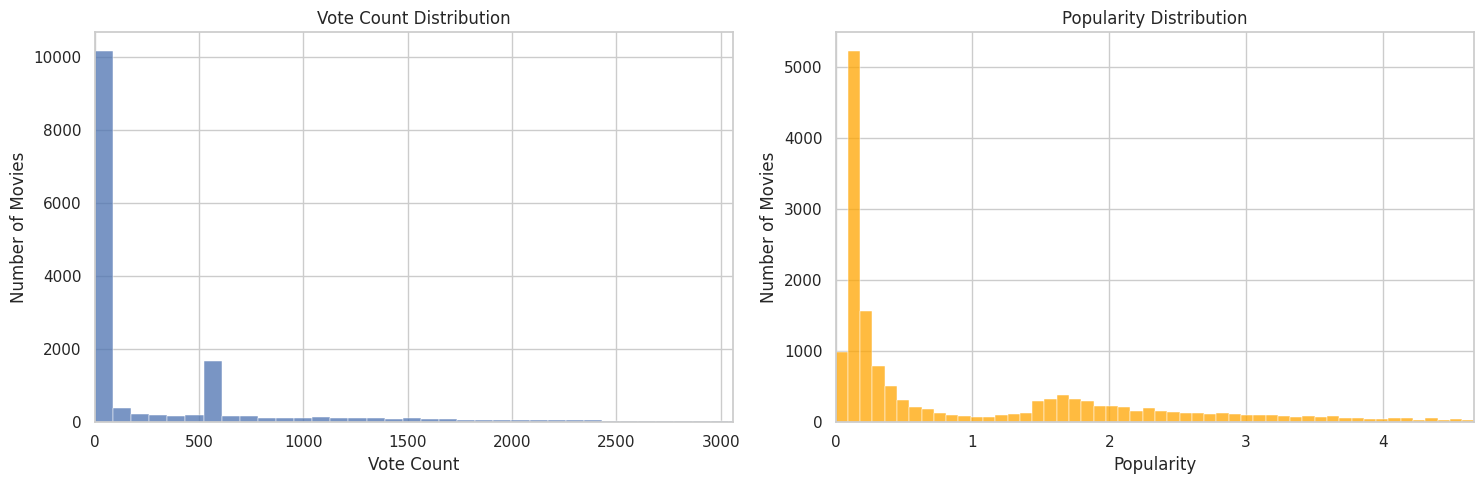

In [ ]:
#Inflation check
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15,5))

plt.subplot(1, 2, 1)
sns.histplot(movies['Vote_Count'], bins=100, kde=False)
plt.title("Vote Count Distribution")
plt.xlabel("Vote Count")
plt.ylabel("Number of Movies")
plt.xlim(0, movies['Vote_Count'].quantile(0.95))

plt.subplot(1, 2, 2)
sns.histplot(movies['Popularity'], bins=100, kde=False, color="orange")
plt.title("Popularity Distribution")
plt.xlabel("Popularity")
plt.ylabel("Number of Movies")
plt.xlim(0, movies['Popularity'].quantile(0.95))

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/Movie_Recommendation/movies.csv")
initial_count = len(df)
vote_threshold = 50
popularity_threshold = 2.0
df = df[~((df['Vote_Count'] < vote_threshold) & (df['Popularity'] > popularity_threshold))]
removed_count = initial_count - len(df)

print(f"Removed {removed_count} records out of {initial_count} total.")

Removed 2437 records out of 25044 total.


In [ ]:
zero_vote_movies = df[df['Vote_Count'] == 0]
print(zero_vote_movies['Popularity'].describe())
popularity_cutoff = 0.1
initial_count = len(df)
df = df[~((df['Vote_Count'] == 0) & (df['Popularity'] <= popularity_cutoff))]
removed_count = initial_count - len(df)
print(f"Removed {removed_count} records with 0 votes and low popularity (≤ {popularity_cutoff}).")

count    6718.000000
mean        0.115083
std         0.109756
min         0.000000
25%         0.051700
50%         0.111650
75%         0.152450
max         1.956300
Name: Popularity, dtype: float64
Removed 3143 records with 0 votes and low popularity (≤ 0.1).


In [ ]:
print(len(df))

19464


In [ ]:
initial_count = len(df)
df = df[~(df["Release Date"].isna() & (df["Popularity"].round(2) == 2.50))]
removed_count = initial_count - len(df)

print(f"Removed {removed_count} records with NaN release dates and suspicious popularity ≈ 2.5.")

Removed 0 records with NaN release dates and suspicious popularity ≈ 2.5.


In [ ]:
#Normalization
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df['Popularity_Norm'] = scaler.fit_transform(df[['Popularity']])

In [ ]:
import numpy as np

df['Popularity_Log'] = np.log1p(df['Popularity'])

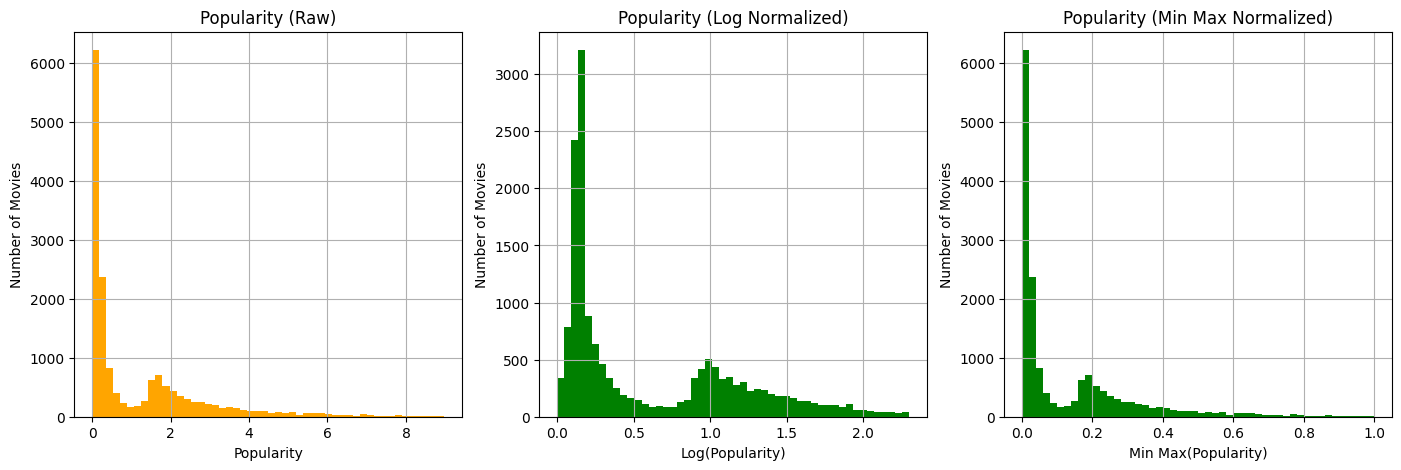

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(17,5))

plt.subplot(1,3,1)
df['Popularity'].hist(bins=50, color='orange')
plt.title("Popularity (Raw)")
plt.xlabel("Popularity")
plt.ylabel("Number of Movies")

plt.subplot(1,3,2)
df['Popularity_Log'].hist(bins=50, color='green')
plt.title("Popularity (Log Normalized)")
plt.xlabel("Log(Popularity)")
plt.ylabel("Number of Movies")

plt.subplot(1,3,3)
df['Popularity_Norm'].hist(bins=50, color='green')
plt.title("Popularity (Min Max Normalized)")
plt.xlabel("Min Max(Popularity)")
plt.ylabel("Number of Movies")

plt.show()

In [ ]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

df['Popularity_Log'] = np.log1p(df['Popularity'])

scaler = MinMaxScaler()
df['Popularity_Scaled'] = scaler.fit_transform(df[['Popularity_Log']])

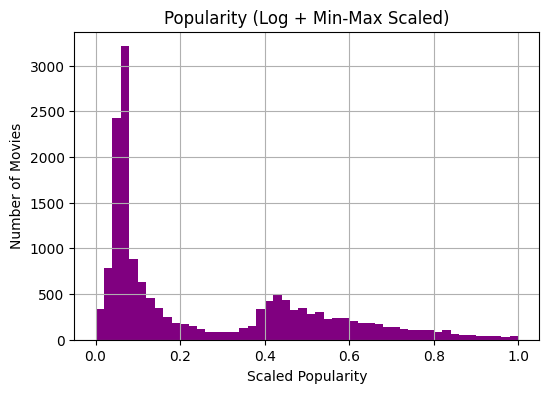

In [ ]:
plt.figure(figsize=(6,4))
df['Popularity_Scaled'].hist(bins=50, color='purple')
plt.title("Popularity (Log + Min-Max Scaled)")
plt.xlabel("Scaled Popularity")
plt.ylabel("Number of Movies")
plt.show()

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler

df['Vote_Count_Log'] = np.log1p(df['Vote_Count'])
scaler = StandardScaler()
df['Vote_Count_Scaled'] = scaler.fit_transform(df[['Vote_Count_Log']])

In [ ]:
threshold = df['Vote_Count'].quantile(0.20)
df = df[df['Vote_Count'] >= threshold]

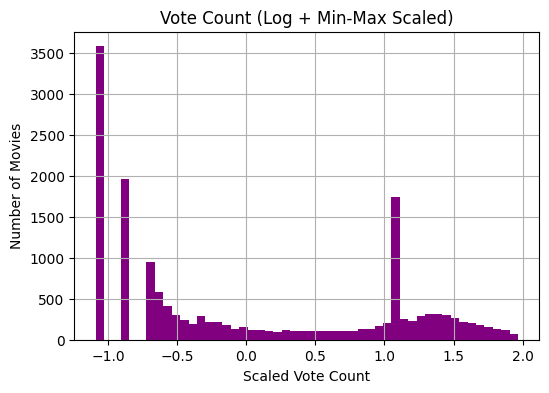

In [ ]:
plt.figure(figsize=(6,4))
df['Vote_Count_Scaled'].hist(bins=50, color='purple')
plt.title("Vote Count (Log + Min-Max Scaled)")
plt.xlabel("Scaled Vote Count")
plt.ylabel("Number of Movies")
plt.show()

In [ ]:
df['release_year'] = pd.to_datetime(df['Release Date'], errors='coerce').dt.year
df = df.drop(columns=['Release Date'])

In [ ]:
df_model = df[['Title', 'Cast', 'Overview', 'Genres', 'Language',
               'release_year', 'Popularity_Scaled', 'Vote_Count_Scaled', 'Rating']]

print(df_model.head())

                       Title  \
0                      evaru   
1  court: state vs. a nobody   
2                      eagle   
3                        sye   
4                     amigos   

                                                Cast  \
0  adivi sesh, regina cassandra, naveen chandra, ...   
1  priyadarshi pullikonda, harsh roshan, sridevi,...   
2  ravi teja, anupama parameswaran, kavya thapar,...   
3  nithiin, genelia d'souza, pradeep ram singh ra...   
4  kalyan ram, ashika ranganath, brahmaji, jayapr...   

                                            Overview                 Genres  \
0                                            unknown        thriller, crime   
1  a determined lawyer takes on a high-stakes cas...  drama, romance, crime   
2  a journalist pieces together the story of eagl...       action, thriller   
3                                            unknown          drama, action   
4                                            unknown       action, thriller

In [ ]:
output_path = "/content/drive/MyDrive/Movie_Recommendation/movies_cleaned.csv"
df.to_csv(output_path, index=False)

print("File saved at:", output_path)

File saved at: /content/drive/MyDrive/Movie_Recommendation/movies_cleaned.csv


In [ ]:
#Feature Extraction
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MultiLabelBinarizer
from sklearn.preprocessing import OneHotEncoder
df = pd.read_csv("/content/drive/MyDrive/Movie_Recommendation/movies_cleaned.csv")
scaler = StandardScaler()
df[['Rating_Scaled']] = scaler.fit_transform(df[['Rating']])

In [ ]:
# Genres (multi-hot encoding)
df['Genres'] = df['Genres'].fillna("").apply(
    lambda x: x if isinstance(x, list) else x.split(",")
)
mlb = MultiLabelBinarizer()
genres_encoded = mlb.fit_transform(df['Genres'])
genres_df = pd.DataFrame(genres_encoded, columns=mlb.classes_)

# Language (one-hot encoding)
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
lang_encoded = ohe.fit_transform(df[['Language']])
lang_df = pd.DataFrame(lang_encoded, columns=ohe.get_feature_names_out(['Language']))

In [ ]:
from transformers import pipeline

emotion_model = pipeline(
    "text-classification",
    model="SamLowe/roberta-base-go_emotions"
)

def get_moods(text, k=2):
    if not isinstance(text, str) or text.strip() == "":
        return "neutral"

    result = emotion_model(text[:300], top_k=k)

    if isinstance(result[0], list):
        result = result[0]

    moods = [r['label'] for r in result[:k]]
    return ", ".join(moods)

df['Overview'] = df['Overview'].fillna("")
df['Moods'] = df['Overview'].apply(lambda x: get_moods(x, k=2))


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/380 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

Device set to use cpu


In [ ]:
df_final = pd.concat([
    df[['Title', 'Cast', 'Overview', 'release_year', 'Popularity_Scaled', 'Vote_Count_Scaled', 'Rating_Scaled', 'Moods']],
    genres_df,
    lang_df
], axis=1)

In [ ]:
output_path = "/content/drive/MyDrive/Movie_Recommendation/movies_features.csv"
df_final.to_csv(output_path, index=False)
print("Features extracted and saved at:", output_path)
print(df_final.head())

Features extracted and saved at: /content/drive/MyDrive/Movie_Recommendation/movies_features.csv
                       Title  \
0                      evaru   
1  court: state vs. a nobody   
2                      eagle   
3                        sye   
4                     amigos   

                                                Cast  \
0  adivi sesh, regina cassandra, naveen chandra, ...   
1  priyadarshi pullikonda, harsh roshan, sridevi,...   
2  ravi teja, anupama parameswaran, kavya thapar,...   
3  nithiin, genelia d'souza, pradeep ram singh ra...   
4  kalyan ram, ashika ranganath, brahmaji, jayapr...   

                                            Overview  release_year  \
0                                            unknown        2019.0   
1  a determined lawyer takes on a high-stakes cas...        2025.0   
2  a journalist pieces together the story of eagl...        2024.0   
3                                            unknown        2004.0   
4                      

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity
from difflib import get_close_matches
import pandas as pd
import numpy as np

df = pd.read_csv("/content/drive/MyDrive/Movie_Recommendation/movies_features.csv")

genre_cols = ['action','adventure','animation','comedy','crime','documentary',
              'drama','family','fantasy','history','horror','music','mystery',
              'romance','science fiction','thriller','tv movie','war','western']

df['Moods'] = df['Moods'].fillna("neutral")
all_moods = set([m.strip().lower() for moods in df['Moods'] for m in moods.split(",")])
for mood in all_moods:
    df[f'mood_{mood}'] = df['Moods'].apply(lambda x: 1 if mood in x.lower() else 0)

df = df[df[genre_cols].sum(axis=1) > 0].copy()
df['Genres'] = df[genre_cols].apply(lambda row: ", ".join([g for g in genre_cols if row[g] == 1]), axis=1)

mood_synonyms = {
    "happy": ["happy", "joy", "cheerful", "happiness", "delighted", "content", "excited", "elated", "ecstatic", "satisfied", "optimistic", "uplifted"],
    "sad": ["sad", "sadness", "disappointment", "melancholy", "unhappy", "gloomy", "heartbroken", "lonely", "down", "mournful", "blue", "depressed"],
    "angry": ["angry", "anger", "rage", "frustration", "annoyed", "irritated", "fuming", "resentful", "agitated", "enraged", "outraged"],
    "fear": ["fear", "scared", "terror", "horror", "afraid", "nervous", "anxious", "uneasy", "panicked", "alarmed", "worried", "shocked"],
    "surprise": ["surprise", "shocked", "astonished", "amazed", "startled", "stunned", "confused", "bewildered", "astounded"],
    "neutral": ["neutral", "calm", "relaxed", "indifferent", "content", "balanced", "serene", "peaceful"],
    "tired": ["tired", "exhausted", "sleepy", "fatigued", "weary", "drowsy", "drained"],
    "bored": ["bored", "uninterested", "apathetic", "disinterested", "listless", "uninspired"],
    "love": ["love", "romantic", "affectionate", "passionate", "lustful", "tender"],
    "confused": ["confused", "puzzled", "uncertain", "doubtful", "perplexed", "disoriented"],
    "curious": ["curious", "inquisitive", "interested", "intrigued", "questioning", "eager"],
    "disappointed": ["disappointed", "let down", "dismayed", "discouraged", "frustrated"],
    "excited": ["excited", "thrilled", "energetic", "enthusiastic", "eager", "elated", "joyful"],
    "fearful": ["fearful", "scared", "anxious", "nervous", "panicked", "afraid", "timid"],
    "relaxed": ["relaxed", "calm", "peaceful", "serene", "content", "comfortable"],
    "nostalgic": ["nostalgic", "sentimental", "wistful", "longing", "reflective"],
    "disgust": ["disgust", "repulsed", "horrified", "offended", "grossed out"]
}

def map_mood(input_mood):
    input_mood = input_mood.lower().strip()
    for key, synonyms in mood_synonyms.items():
        closest = get_close_matches(input_mood, synonyms, n=1, cutoff=0.6)
        if closest:
            for syn in synonyms:
                col_name = f"mood_{syn}"
                if col_name in df.columns:
                    return syn
    return None

numerical_features = ['release_year','Popularity_Scaled','Vote_Count_Scaled','Rating_Scaled']
scaler = MinMaxScaler()
X_num = scaler.fit_transform(df[numerical_features].fillna(0))

binary_features = genre_cols + [c for c in df.columns if c.startswith("mood_")]
X_bin = df[binary_features].fillna(0).values

X = np.hstack([X_bin*2.0, X_num])
similarity_matrix = cosine_similarity(X, X)

def recommend_by_mood(input_mood, n=5):
    mapped = map_mood(input_mood)
    if not mapped:
        print(f"No mood found matching '{input_mood}'")
        return pd.DataFrame()
    col_name = f"mood_{mapped}"
    mood_movies = df[df[col_name]==1].copy()
    if mood_movies.empty:
        print(f"No movies found for mood '{mapped}'")
        return pd.DataFrame()
    mood_movies = mood_movies.sort_values('Rating_Scaled', ascending=False)
    print(f"Matching mood used: '{mapped}'")
    return mood_movies.head(n)[['Title','Moods','Genres','Rating_Scaled']]

def display(df_rec):
    if df_rec.empty:
        print("No recommendations found.")
        return
    for i,row in enumerate(df_rec.itertuples(),1):
        print(f"{i}. {row.Title} | Genres: {row.Genres} | Moods: {row.Moods} | Rating: {row.Rating_Scaled:.2f}")

print("\nMood-based recommendation for 'tired':")
display(recommend_by_mood("happy", n=10))